# Bayesian Change Point Detection for Price Zones

This notebook uses the `ruptures` library to identify distinct price zones in TSLA 1h data using Bayesian-style change point detection.

**Key Concepts:**
- PELT algorithm with RBF kernel for detecting mean shifts
- Bayesian Information Criterion (BIC) penalty controls zone sensitivity
- Zones represent periods of price consolidation or distinct regimes

## Cell 1: Install ruptures (run once)

In [ ]:
# Run this cell once if ruptures is not installed
!pip install ruptures

## Cell 2: Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt
from matplotlib.patches import Rectangle
import sys
sys.path.append('..')

from src.data_loader import DataLoader

# Load TSLA 1h data
loader = DataLoader(symbol='TSLA')
df = loader.get_data('1h', force_refresh=False)

print(f"Loaded {len(df)} candles")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"Price range: ${df['close'].min():.2f} to ${df['close'].max():.2f}")

📂 Loaded 5000 candles from cache: /Users/nikolastsalidis/Desktop/smart-money-concepts/notebooks/../data/tsla/tsla_1h.csv
Loaded 5000 candles
Date range: 2023-03-09 20:30:00 to 2026-01-16 19:30:00
Price range: $140.16 to $494.94


## Cell 3: Bayesian Change Point Detection

In [2]:
def detect_price_zones(prices: np.ndarray, penalty: float = 3.0, min_size: int = 10):
    """
    Detect change points in price data using Bayesian-style penalty.

    Args:
        prices: Array of close prices
        penalty: Bayesian Information Criterion penalty (higher = fewer zones)
                 - 1-2: Many zones (sensitive)
                 - 3-5: Moderate zones (balanced)
                 - 10+: Few zones (conservative)
        min_size: Minimum segment length between change points

    Returns:
        change_points: List of indices where regime changes occur
    """
    # Normalize prices for better numerical stability
    prices_normalized = (prices - prices.mean()) / prices.std()

    # PELT algorithm with RBF kernel (good for detecting mean shifts)
    # "rbf" cost function is robust to outliers and captures level changes
    algo = rpt.Pelt(model="rbf", min_size=min_size).fit(prices_normalized)

    # Predict change points using Bayesian Information Criterion penalty
    change_points = algo.predict(pen=penalty)

    return change_points

# Extract close prices
prices = df['close'].values

# Detect change points (adjust penalty to control sensitivity)
PENALTY = 3.0  # Adjust this: lower = more zones, higher = fewer zones
change_points = detect_price_zones(prices, penalty=PENALTY)

print(f"Found {len(change_points)} change points (zones)")
print(f"Change point indices: {change_points}")

Found 44 change points (zones)
Change point indices: [195, 345, 400, 440, 545, 635, 730, 830, 1080, 1205, 1475, 1540, 1730, 1930, 1980, 2275, 2305, 2405, 2680, 2795, 2860, 2925, 2940, 3060, 3080, 3105, 3170, 3325, 3360, 3430, 3485, 3560, 3625, 3720, 3800, 3915, 4225, 4390, 4430, 4700, 4770, 4845, 4910, 5000]


## Cell 4: Extract Zone Statistics

In [3]:
def extract_zones(df: pd.DataFrame, change_points: list) -> pd.DataFrame:
    """
    Extract zone statistics from change points.

    Returns DataFrame with zone info: start, end, mean price, std, duration
    """
    zones = []

    # Add 0 as start point if not present
    all_points = [0] + change_points

    for i in range(len(all_points) - 1):
        start_idx = all_points[i]
        end_idx = all_points[i + 1]

        zone_df = df.iloc[start_idx:end_idx]

        zones.append({
            'zone_id': i + 1,
            'start_idx': start_idx,
            'end_idx': end_idx,
            'start_time': zone_df['time'].iloc[0],
            'end_time': zone_df['time'].iloc[-1],
            'duration_candles': len(zone_df),
            'mean_price': zone_df['close'].mean(),
            'std_price': zone_df['close'].std(),
            'min_price': zone_df['low'].min(),
            'max_price': zone_df['high'].max(),
            'price_range': zone_df['high'].max() - zone_df['low'].min(),
        })

    return pd.DataFrame(zones)

# Extract zone statistics
zones_df = extract_zones(df, change_points)
print("\n=== Price Zones ===")
print(zones_df[['zone_id', 'start_time', 'end_time', 'duration_candles', 'mean_price', 'price_range']].to_string(index=False))


=== Price Zones ===
 zone_id          start_time            end_time  duration_candles  mean_price  price_range
       1 2023-03-09 20:30:00 2023-04-19 18:30:00               195  186.980211    43.879990
       2 2023-04-19 19:30:00 2023-05-18 21:30:00               150  165.827918    31.130000
       3 2023-05-19 15:30:00 2023-05-31 20:30:00                55  188.873118    27.780000
       4 2023-05-31 21:30:00 2023-06-08 18:30:00                40  217.975141    34.690000
       5 2023-06-08 19:30:00 2023-06-30 18:30:00               105  255.694417    46.139980
       6 2023-06-30 19:30:00 2023-07-20 17:30:00                90  278.575872   136.933310
       7 2023-07-20 18:30:00 2023-08-08 21:30:00                95  260.305555    30.140000
       8 2023-08-09 15:30:00 2023-08-29 16:30:00               100  234.245958    39.530000
       9 2023-08-29 17:30:00 2023-10-18 21:30:00               250  256.734477    44.400010
      10 2023-10-19 15:30:00 2023-11-13 20:30:00           

## Cell 5: Visualization

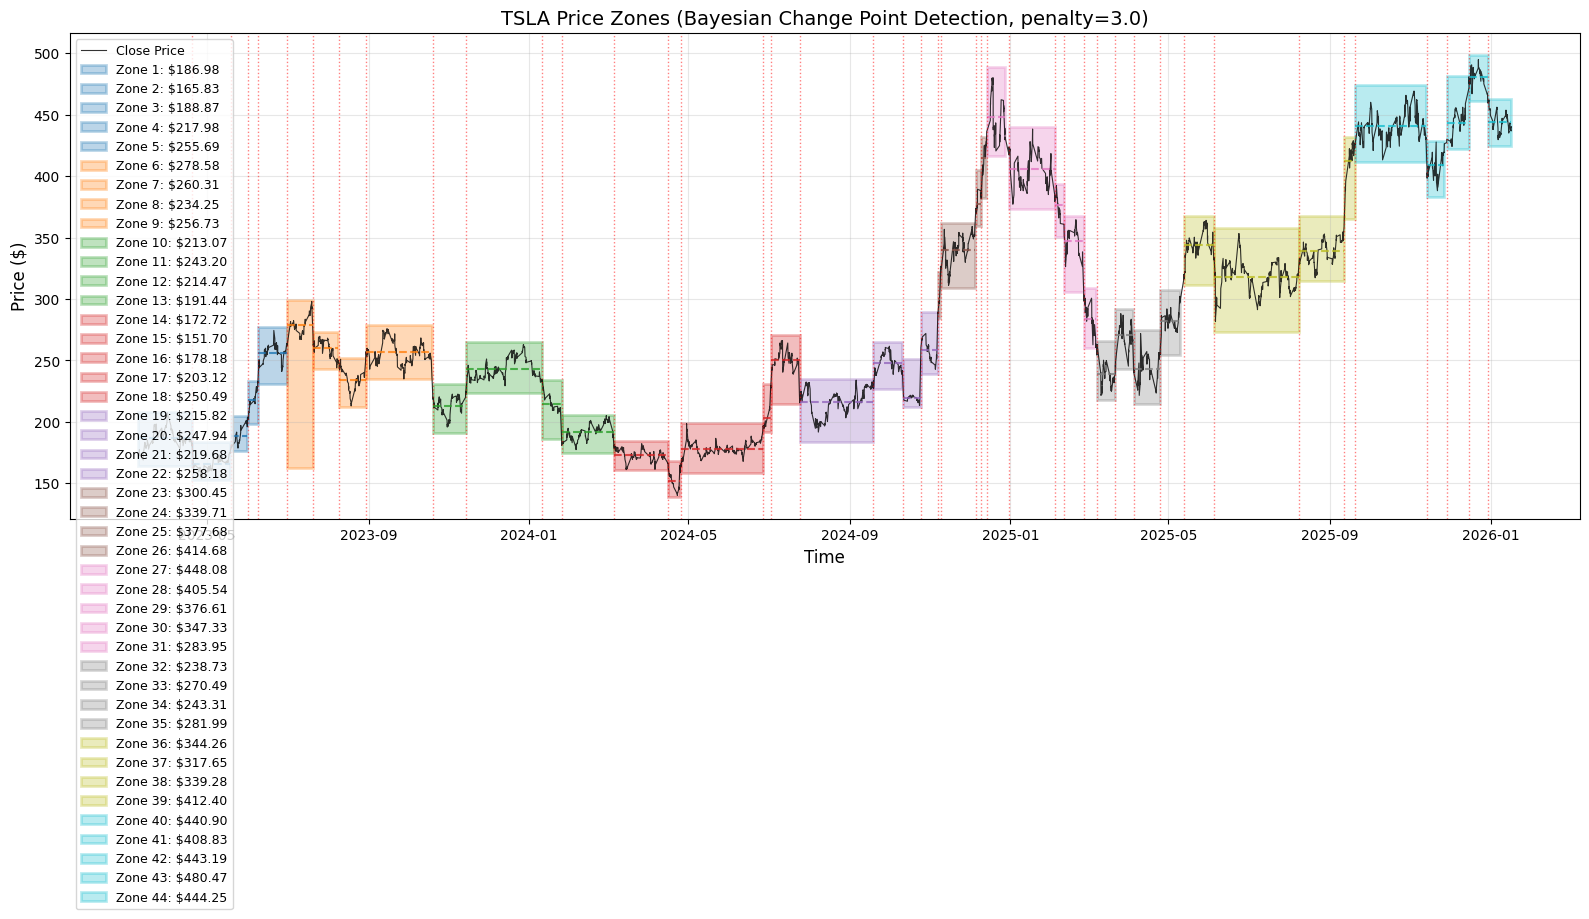

In [4]:
def plot_price_zones(df: pd.DataFrame, change_points: list, zones_df: pd.DataFrame):
    """
    Plot price chart with zones highlighted.
    """
    fig, ax = plt.subplots(figsize=(16, 8))

    # Color palette for zones
    colors = plt.cm.tab10(np.linspace(0, 1, len(zones_df)))

    # Plot price line
    ax.plot(df['time'], df['close'], color='black', linewidth=0.8, alpha=0.8, label='Close Price')

    # Add zone rectangles
    for i, zone in zones_df.iterrows():
        start_time = zone['start_time']
        end_time = zone['end_time']
        min_price = zone['min_price']
        max_price = zone['max_price']

        # Draw rectangle for zone
        rect = Rectangle(
            (start_time, min_price),
            end_time - start_time,
            max_price - min_price,
            facecolor=colors[i],
            alpha=0.3,
            edgecolor=colors[i],
            linewidth=2,
            label=f"Zone {zone['zone_id']}: ${zone['mean_price']:.2f}"
        )
        ax.add_patch(rect)

        # Add zone mean line
        ax.hlines(
            zone['mean_price'],
            start_time,
            end_time,
            colors=colors[i],
            linestyles='--',
            linewidth=1.5,
            alpha=0.8
        )

    # Mark change points with vertical lines
    for cp in change_points[:-1]:  # Exclude last point (end of data)
        if cp < len(df):
            ax.axvline(df['time'].iloc[cp], color='red', linestyle=':', alpha=0.5, linewidth=1)

    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.set_title(f'TSLA Price Zones (Bayesian Change Point Detection, penalty={PENALTY})', fontsize=14)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig

# Plot the zones
fig = plot_price_zones(df, change_points, zones_df)

## Cell 6: Interactive Penalty Tuning (Optional)

In [5]:
# Try different penalty values to see how it affects zone detection
def compare_penalties(prices, penalties=[1, 3, 5, 10]):
    """Compare zone detection with different penalty values."""
    fig, axes = plt.subplots(len(penalties), 1, figsize=(14, 3*len(penalties)), sharex=True)

    for ax, pen in zip(axes, penalties):
        cps = detect_price_zones(prices, penalty=pen)

        ax.plot(prices, 'k-', linewidth=0.5)
        for cp in cps[:-1]:
            ax.axvline(cp, color='red', alpha=0.7, linewidth=1)

        ax.set_title(f'Penalty = {pen} -> {len(cps)} zones')
        ax.set_ylabel('Price')

    axes[-1].set_xlabel('Candle Index')
    plt.tight_layout()
    plt.show()

# Uncomment to compare:
# compare_penalties(prices, penalties=[1, 2, 3, 5, 10])

## Key Parameters to Tune

| Parameter | Effect | Recommended |
|-----------|--------|-------------|
| `penalty` | Controls number of zones. Higher = fewer, more stable zones | Start with 3.0, adjust based on results |
| `min_size` | Minimum candles per zone | 10-50 depending on timeframe |

## Verification
1. Run cells in order
2. Check zone count is reasonable (5-15 for typical price history)
3. Visually verify zones correspond to consolidation periods
4. Adjust `PENALTY` value if too many/few zones